# Модель Росса: базовый прогон

В системе постоянно работают $N$ машин, ещё $S$ машин стоят в резерве.
Когда машина ломается, её заменяют резервной, а сломанную отправляют
в ремонт. Если машина сломалась, а резерва нет, система падает.
В этом скрипте выполняется код из методических указаний, считается
загрузка ремонтника и длина очереди на ремонт и строится график числа
исправных машин.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(RossModel) || include(srcdir("RossModel.jl"))
using .RossModel
using DataFrames, CSV, Plots, Statistics
using StableRNGs

script_name = "ross_run"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab07/project/data"

## Параметры модели

Десять работающих машин, три резервные и один ремонтник.
Среднее время работы машины до отказа равно 100 часам,
среднее время ремонта равно одному часу.

In [2]:
RUNS = 5
N = 10
S = 3
R = 1
LAMBDA = 100
MU = 1

1

## Запуск моделирования

Выполняется пять прогонов, для каждого печатается время падения системы.

In [3]:
ross_rng = StableRNG(42)
runs = [sim_repair(ross_rng; N = N, S = S, R = R, lambda = LAMBDA, mu = MU, verbose = true) for i = 1:RUNS]
crash_times = [r[1] for r in runs]
println("Average crash time: ", sum(crash_times) / RUNS)

At time 12715.718224958666: No more spares!
At time 37335.53567595007: No more spares!
At time 30844.62667837361: No more spares!
At time 1601.2524911974856: No more spares!
At time 824.1048708405848: No more spares!
Average crash time: 16664.247588264083


## Сравнение с аналитическим решением

Среднее время до падения находится из системы линейных уравнений
для марковской цепи.

In [4]:
T_theory = ross_analytic(N = N, S = S, R = R, lambda = LAMBDA, mu = MU)
println("Аналитическое среднее время до падения: ", round(T_theory, digits = 1))

Аналитическое среднее время до падения: 12340.0


## Мониторинг ремонтника

Для каждого прогона считаем загрузку ремонтника, среднюю длину
очереди на ремонт и среднее число сломанных машин.

In [5]:
df_monitor = DataFrame([
    merge((run = i, crash_time = round(runs[i][1], digits = 1)), map(x -> round(x, digits = 4), ross_monitor(runs[i][2], runs[i][1]; R = R))) for i = 1:RUNS
])
CSV.write(datadir("ross_run.csv"), df_monitor)
println(df_monitor)

5×5 DataFrame
 Row │ run    crash_time  utilization  mean_queue  mean_broken 
     │ Int64  Float64     Float64      Float64     Float64     
─────┼─────────────────────────────────────────────────────────
   1 │     1     12715.7       0.1018      0.0127       0.1146
   2 │     2     37335.5       0.0997      0.0112       0.1109
   3 │     3     30844.6       0.1008      0.0102       0.111
   4 │     4      1601.3       0.1063      0.0146       0.1209
   5 │     5       824.1       0.1103      0.0177       0.128


## График числа исправных машин

Слева показан весь первый прогон, справа --- последние 50 часов перед
падением. Пунктирная линия отмечает уровень $N$: система падает,
когда число исправных машин опускается ниже него.

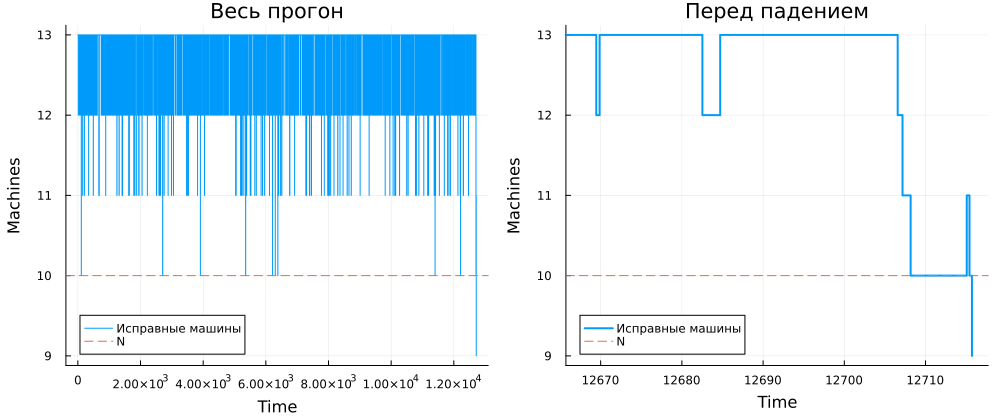

In [6]:
timeline = ross_timeline(runs[1][2]; N = N, S = S)
T_first = runs[1][1]
p1 = plot(
    timeline.times,
    timeline.healthy,
    seriestype = :steppost,
    label = "Исправные машины",
    xlabel = "Time",
    ylabel = "Machines",
    title = "Весь прогон",
)
hline!(p1, [N], linestyle = :dash, label = "N")
p2 = plot(
    timeline.times,
    timeline.healthy,
    seriestype = :steppost,
    linewidth = 2,
    label = "Исправные машины",
    xlabel = "Time",
    ylabel = "Machines",
    title = "Перед падением",
    xlims = (T_first - 50, T_first + 2),
)
hline!(p2, [N], linestyle = :dash, label = "N")
plt_ross = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
savefig(plt_ross, plotsdir("ross_healthy.png"))
plt_ross

## Итог

In [7]:
println("Базовый прогон модели Росса завершён. Результаты в data/ и plots/")

Базовый прогон модели Росса завершён. Результаты в data/ и plots/
